In [9]:
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, recall_score
import matplotlib.pyplot as plt
import seaborn as sns


df_tuesday = pd.read_csv("../data/processed/Tuesday/Tuesday_final_labeled_features.csv")
df_wednesday = pd.read_csv("../data/processed/Wednesday/Wednesday_final_labeled_features.csv")

df = pd.concat([df_tuesday, df_wednesday], ignore_index=True)

print(f"[+] Combined Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns.")

[+] Combined Dataset Shape: 614254 rows and 116 columns.


In [10]:
contaminants = [
    # Identifiers & Timestamps
    'id', 'uid', 'src_ip', 'dst_ip', 'src_mac', 'dst_mac', 
    'src_oui', 'dst_oui', 'vlan_id', 'tunnel_id', 'src_port', 'dst_port',
    'datetime', 'ts', 'ts_ms', 'bidirectional_first_seen_ms', 
    'bidirectional_last_seen_ms', 'src2dst_first_seen_ms', 
    'src2dst_last_seen_ms', 'dst2src_first_seen_ms', 'dst2src_last_seen_ms',
    
    # L7 Plaintext Leaks (The "Cheating" Features)
    'application_name', 'application_category_name', 'application_is_guessed', 
    'application_confidence', 'content_type', 'user_agent',
    'http_requests', 'http_error_codes',
    'ftp_user', 'ftp_failed_auths', 'ftp_success_auths',
    'ssh_auth_success', 'ssh_auth_attempts', 'ssh_client', 'ssh_flows_past_60s', 
    
    'sni_domain', 'cipher_suite', 'tls_version', 'tls_resumed',
    'requested_server_name', 'client_fingerprint', 'server_fingerprint'
]

In [11]:
print("[*] Engineering Tier 1 Binary Labels...")
df['tier1_label'] = df['label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

contaminants.append('label') 
cols_to_drop = [c for c in contaminants if c in df.columns]
df = df.drop(columns=cols_to_drop)

X = df.drop(columns=['tier1_label'])
y = df['tier1_label']

print(f"[+] Final Feature Matrix Shape: {X.shape}")
print(f"[+] Class Distribution:\n{y.value_counts(normalize=True) * 100}")

[*] Engineering Tier 1 Binary Labels...
[+] Final Feature Matrix Shape: (614254, 97)
[+] Class Distribution:
tier1_label
0    94.166745
1     5.833255
Name: proportion, dtype: float64


In [12]:
print("[*] Performing Train/Test Split (80/20)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set: {X_test.shape[0]} rows")

[*] Performing Train/Test Split (80/20)...
Training set: 491403 rows
Testing set: 122851 rows


In [13]:
print("[*] Building Scikit-Learn Pipelines...")

categorical_cols = X_train.select_dtypes(include=['object', 'bool']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=0.01))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

[*] Building Scikit-Learn Pipelines...


In [14]:
print("[*] Fitting Preprocessor and Training Logistic Regression...")

tier1_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,          
        n_jobs=-1               
    ))
])

tier1_pipeline.fit(X_train, y_train)
print("[+] Tier 1 Model Training Complete!")

[*] Fitting Preprocessor and Training Logistic Regression...
[+] Tier 1 Model Training Complete!


[*] Evaluating Model on Unseen Test Data...

--- Classification Report ---
              precision    recall  f1-score   support

  Benign (0)       1.00      0.99      1.00    115685
 Anomaly (1)       0.91      1.00      0.95      7166

    accuracy                           0.99    122851
   macro avg       0.96      1.00      0.97    122851
weighted avg       0.99      0.99      0.99    122851


[!] TIER 1 RECALL SCORE: 0.9979


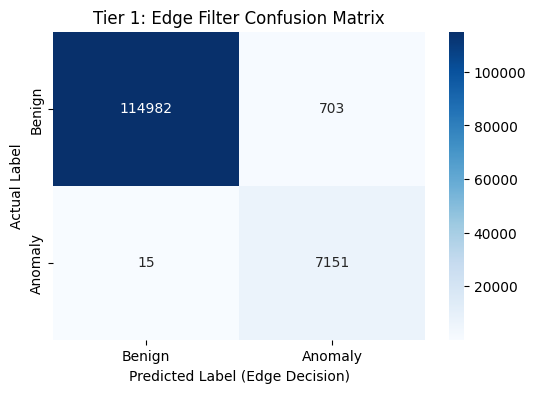

[+] Pipeline saved to models/tier1_edge_pipeline.pkl


In [15]:
print("[*] Evaluating Model on Unseen Test Data...")
y_pred = tier1_pipeline.predict(X_test)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Anomaly (1)']))

recall = recall_score(y_test, y_pred)
print(f"\n[!] TIER 1 RECALL SCORE: {recall:.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Anomaly'], yticklabels=['Benign', 'Anomaly'])
plt.title('Tier 1: Edge Filter Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label (Edge Decision)')
plt.show()

os.makedirs("../models", exist_ok=True)
joblib.dump(tier1_pipeline, '../models/tier1_edge_pipeline.pkl')
print("[+] Pipeline saved to models/tier1_edge_pipeline.pkl")

In [16]:
import pandas as pd
import numpy as np

numeric_features = preprocessor.transformers_[0][2]

categorical_features = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)
all_features = numeric_features + list(categorical_features)

weights = tier1_pipeline.named_steps['classifier'].coef_[0]

feature_importance = pd.DataFrame({'Feature': all_features, 'Weight': weights})

feature_importance['Abs_Weight'] = feature_importance['Weight'].abs()
feature_importance = feature_importance.sort_values(by='Abs_Weight', ascending=False)

print("\n--- Top 15 Most Important Features ---")
print(feature_importance[['Feature', 'Weight']].head(15))


--- Top 15 Most Important Features ---
                     Feature     Weight
0                   protocol -15.617929
32      dst2src_mean_piat_ms  13.078469
95                history_Dd -11.300358
7              src2dst_bytes -11.176384
13   bidirectional_stddev_ps -10.381016
21         dst2src_stddev_ps  10.346477
89            splt_piat_ms_4 -10.046422
20           dst2src_mean_ps   9.404448
87            splt_piat_ms_2  -9.223502
12     bidirectional_mean_ps  -8.336304
14      bidirectional_max_ps  -8.210530
108            conn_state_SF  -7.871058
105          conn_state_RSTO  -7.465543
107            conn_state_S0   6.991186
106          conn_state_RSTR  -6.697040
